In [2]:
import numpy as np
import plotly.graph_objs as go
import random
import os
import sys

使用自己确定的立方体划分方案，转换为四面体网格,并保存为`.msh`格式

/home/yiliao/anaconda3/envs/py3.8/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning:

Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/yiliao/anaconda3/envs/py3.8/lib/python3.8/site-packages/trame/widgets/__init__.py)

Falling back to a static output.



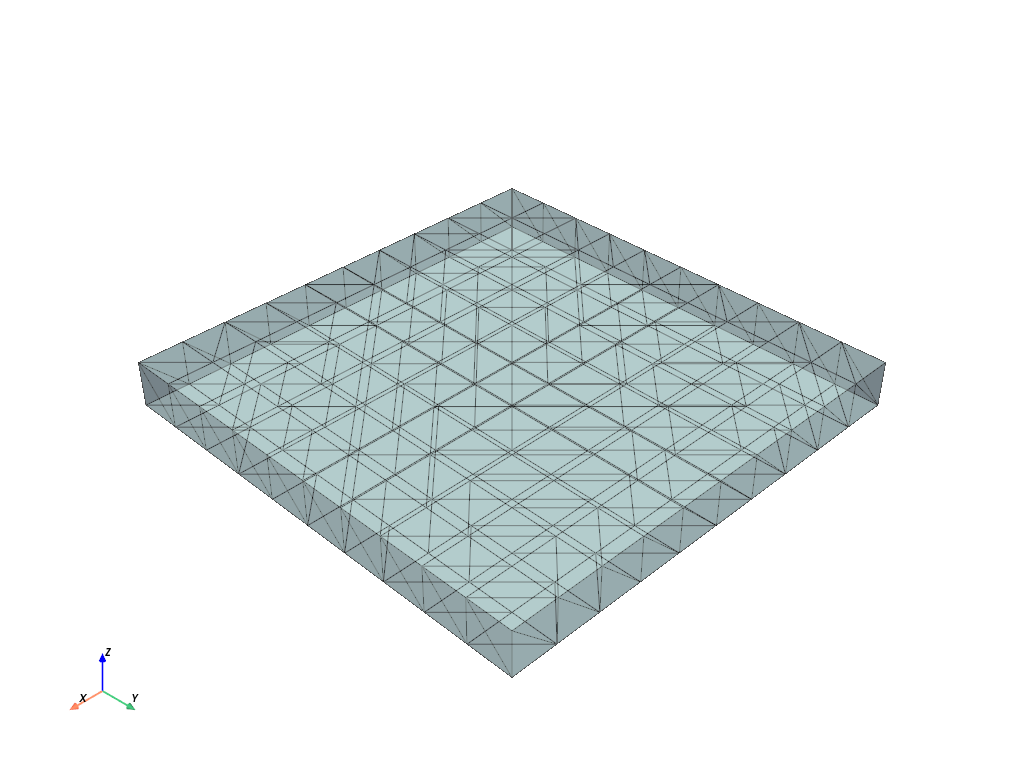

Mesh data has been written to cube_new.msh


In [7]:
import pyvista as pv
project_root = os.path.abspath("../..")  # 根据你的结构，Mesh 文件夹的上一级是根目录
sys.path.append(project_root)
from _GenMsh import write_element

# 1. 生成均匀分布的采样节点
x_gap, y_gap, z_gap = 0.05, 0.05, 0.05  # 每个方向的间隙
x_range, y_range, z_range = (0, 0.5), (0, 0.5), (0, 0.05)  # 长方体范围

x = np.arange(x_range[0], x_range[1] + x_gap, x_gap)
y = np.arange(y_range[0], y_range[1] + y_gap, y_gap)
z = np.arange(z_range[0], z_range[1] + z_gap, z_gap)

# 先排最后一个维度，再排倒数第二个维度，最后排第一个维度
xx, yy, zz = np.meshgrid(x, y, z, indexing='ij')
points = np.vstack([xx.ravel(), yy.ravel(), zz.ravel()]).T

# 2. 生成规则的四面体网格
cells = []
num_x, num_y, num_z = len(x) - 1, len(y) - 1, len(z) - 1

# 定义多种长方体划分为四面体的方式,只适合`Z方向`仅有一个单位的情况
def generate_random_tetrahedra(v0, v1, v2, v3, v4, v5, v6, v7):
    options = [
        # 划分方案 1，选择对角线 v1-v6，相对于 v0-v7
        [[4, v0, v1, v2, v6], [4, v1, v2, v3, v7], [4, v1, v2, v6, v7], [4, v0, v1, v5, v6], [4, v1, v5, v6, v7], [4, v0, v4, v5, v6]],
        # # 划分方案 2，选择对角线 v0-v7，相对于 v1-v6
        # [[4, v0, v1, v5, v7], [4, v0, v4, v6, v7], [4, v0, v4, v5, v7], [4, v0, v1, v3, v7], [4, v0, v3, v6, v7], [4, v0, v2, v3, v6]],
        # 划分方案 3，选择对角线 v2-v5，相对于 v3-v4
        [[4, v1, v2, v3, v5], [4, v0, v2, v4, v5], [4, v0, v1, v2, v5], [4, v2, v3, v5, v7], [4, v2, v4, v5, v6], [4, v2, v5, v6, v7]]
        # 划分方案 4，选择对角线 v3-v4，相对于 v2-v5
        # [[4, v0, v1, v3, v4], [4, v1, v3, v4, v7], [4, v1, v4, v5, v7], [4, v0, v2, v3, v4], [4, v3, v4, v6, v7], [4, v2, v3, v4, v6]]
    ]
    return random.choice(options)

# 遍历每个小长方体，生成随机划分的四面体
for i in range(num_x):
    for j in range(num_y):
        for k in range(num_z):
            # 获取小长方体的8个顶点索引
            # v0=[0,0,0]; v1=[0,0,1]; v2=[0,1,0]; v3=[0,1,1]; v4=[1,0,0]; v5=[1,0,1]; v6=[1,1,0]; v7=[1,1,1]
            v0 = i * (num_y + 1) * (num_z + 1) + j * (num_z + 1) + k
            v1 = v0 + 1
            v2 = v0 + (num_z + 1)
            v3 = v2 + 1
            v4 = v0 + (num_y + 1) * (num_z + 1)
            v5 = v4 + 1
            v6 = v4 + (num_z + 1)
            v7 = v6 + 1

            # 随机选择一种划分方式
            tetrahedra = generate_random_tetrahedra(v0, v1, v2, v3, v4, v5, v6, v7)
            cells.extend(tetrahedra)

# 3. 使用 PyVista 进行可视化
# 创建一个 PyVista 的 UnstructuredGrid 对象
ugrid = pv.UnstructuredGrid(
    np.hstack(cells), np.array([10] * len(cells)), points
)

# 可视化四面体网格
plotter = pv.Plotter()
plotter.add_mesh(ugrid, show_edges=True, opacity=0.5)
plotter.show_axes()
plotter.show()

cells_np = np.array(cells)
np.savetxt('node.csv', points, delimiter=',', fmt='%f')
np.savetxt('element.csv', cells_np[:,1:], delimiter=',', fmt='%d')

write_element('cube_new.msh', points, cells_np[:,1:])

In [6]:
node_np = np.loadtxt('node.csv', delimiter=',')

# 创建三维数据
x = node_np[:, 0]
y = node_np[:, 1]
z = node_np[:, 2]

# 创建散点图
fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=3.,
        color=z,  # 根据z值设定颜色
        colorscale='Viridis',  # 设置颜色范围
        opacity=0.8
    )
)])

# 设置布局和轴标签
fig.update_layout(
    scene=dict(
        xaxis_title='X Axis',
        yaxis_title='Y Axis',
        zaxis_title='Z Axis'
    ), autosize=False, width=800, height=600
)

# 展示图表
fig.show()

---
将相关的 .msh 文件中的 element 信息写入

In [4]:
import os
import sys
# # 添加项目目录到 sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(project_root)
# 导入的时候注意是否改了工作目录
from Utilize.GenMsh import read_elements_from_msh2

# 添加脚本所在目录到 sys.path
script_dir = os.path.abspath(os.getcwd())  # 假设 cube_new.msh 在 script 目录

points, elements = read_elements_from_msh2(f'{script_dir}/cube_new.msh')

elements_np = np.array([element[1] for element in elements])
elements_np = elements_np - 1  # 从 0 开始编号
np.savetxt(f'{script_dir}/cube_new_element.csv', elements_np, delimiter=',', fmt='%d')